# Assignment 5: Feature Engineering & Data Preparation
**Machine Learning & AI BootCamp**  
*Instructor: Fahd*  
*Difficulty Level: Easy (Unique Case Study: SoundWave Music Platform)*

---

### 📌 Instructions & Guidelines:
1. Complete all 8 exercises by writing your code directly below each `# TODO:` comment.
2. The assignment uses `soundwave_music_users.csv`, a real-world dataset from a music streaming service tracking listening behavior, skips, subscription tiers, and churn risk.
3. Follow the steps sequentially. Each exercise tests concepts from **Class 9 (Feature Engineering & Encoding)** and **Class 10 (Train-Test Split & Data Leakage Prevention)**.
4. Always follow the **Golden Rule of Data Leakage Prevention**: fit your transformers strictly on training data!


---
## Student Information
- **Student Name:Abu Hasan
- **Batch:** *AI/ML-02
- **Date:** *[29-09-2026]*


In [1]:
# Run this cell first to import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

print("All required libraries successfully imported!")


All required libraries successfully imported!


In [2]:
# TODO 1.1: Load the dataset
url = "https://github.com/ABUHASANCSE/Assignment/raw/refs/heads/main/soundwave_music_users.xlsx"

df = pd.read_excel(url)

df.head()

,user_id,signup_date,age,subscription_tier,primary_genre,daily_listen_mins,songs_skipped_per_day,playlists_created,device_type,churn_risk
0,SW-1001,2023-01-15,24,Free,Hip-Hop,45,18,1,Mobile,1
1,SW-1002,2022-11-04,38,Gold,Rock,130,4,8,Desktop,0
2,SW-1003,2023-03-20,29,Silver,Pop,85,9,4,Mobile,0
3,SW-1004,2021-08-12,45,Gold,Jazz,150,3,12,Smart Speaker,0
4,SW-1005,2023-05-28,19,Free,Electronic,35,22,0,Mobile,1


---
## Exercise 1: Loading & Inspecting the SoundWave Dataset
1. Load `soundwave_music_users.csv` into a DataFrame named `df`.
2. Display the shape of the DataFrame and the first 5 rows.
3. Check the class distribution of the target column `churn_risk` using `.value_counts()`.


In [3]:
# TODO 1.2: Display shape and first 5 rows

df.shape


(40, 10)

In [4]:
# TODO 1.3: Check churn_risk counts
df['churn_risk'].value_counts()

churn_risk
0    30
1    10
Name: count, dtype: int64

---
## Exercise 2: Datetime Feature Engineering
Timestamps contain rich seasonal and tenure signals.
1. Convert `signup_date` into a `datetime64[ns]` data type using `pd.to_datetime()`.
2. Create a new column `signup_month` containing the integer month (1 to 12).
3. Create a new column `signup_day_name` containing the day of the week name (e.g. Monday, Tuesday) using `.dt.day_name()`.
4. Calculate `tenure_days`: the number of days between the user's signup date and `'2024-01-01'` (hint: `(pd.to_datetime('2024-01-01') - df['signup_date']).dt.days`).
5. Display the first 5 rows of these newly created datetime features.


In [5]:
# TODO 2.1: Convert signup_date to datetime
df['signup_date'].dtype

dtype('<M8[us]')

In [6]:
# TODO 2.2: Extract signup_month
df['month']=df['signup_date'].dt.month

In [7]:
# TODO 2.3: Extract signup_day_name
df['day']=df['signup_date'].dt.day_name()

In [8]:
# TODO 2.4: Calculate tenure_days relative to 2024-01-01
df['tenure_days']=pd.Timestamp('2024-01-01') - df['signup_date']
df['tenure_days'] = df['tenure_days'].dt.days

In [9]:
# TODO 2.5: Display first 5 rows of datetime columns
df.head(5)

,user_id,signup_date,age,subscription_tier,primary_genre,daily_listen_mins,songs_skipped_per_day,playlists_created,device_type,churn_risk,month,day,tenure_days
0,SW-1001,2023-01-15,24,Free,Hip-Hop,45,18,1,Mobile,1,1,Sunday,351
1,SW-1002,2022-11-04,38,Gold,Rock,130,4,8,Desktop,0,11,Friday,423
2,SW-1003,2023-03-20,29,Silver,Pop,85,9,4,Mobile,0,3,Monday,287
3,SW-1004,2021-08-12,45,Gold,Jazz,150,3,12,Smart Speaker,0,8,Thursday,872
4,SW-1005,2023-05-28,19,Free,Electronic,35,22,0,Mobile,1,5,Sunday,218


---
## Exercise 3: Domain-Specific Feature Creation
In music streaming, a user who skips a lot of songs relative to their listening time might be unsatisfied and at higher risk of churning!
1. Calculate the estimated number of songs listened to per day, assuming an average song length of **3.5 minutes**:  
   $$\text{songs\_listened} = \frac{\text{daily\_listen\_mins}}{3.5}$$
2. Create a new feature `skip_rate`:  
   $$\text{skip\_rate} = \frac{\text{songs\_skipped\_per\_day}}{\text{songs\_listened}}$$
3. Create a binary flag `is_curator`: $1$ if `playlists_created >= 5`, and $0$ otherwise.
4. Display the first 5 rows of `['daily_listen_mins', 'songs_skipped_per_day', 'skip_rate', 'is_curator']`.


In [10]:
# TODO 3.1 & 3.2: Calculate skip_rate
df['skip_rate']=df['songs_skipped_per_day']/df['daily_listen_mins'] *100

In [11]:
# TODO 3.3: Create is_curator binary flag
df['is_curator'] = (df['playlists_created'] >= 5).astype(int)

In [12]:
# TODO 3.4: Display the first 5 rows of the new features
df.head()

,user_id,signup_date,age,subscription_tier,primary_genre,daily_listen_mins,songs_skipped_per_day,playlists_created,device_type,churn_risk,month,day,tenure_days,skip_rate,is_curator
0,SW-1001,2023-01-15,24,Free,Hip-Hop,45,18,1,Mobile,1,1,Sunday,351,40.000000,0
1,SW-1002,2022-11-04,38,Gold,Rock,130,4,8,Desktop,0,11,Friday,423,3.076923,1
2,SW-1003,2023-03-20,29,Silver,Pop,85,9,4,Mobile,0,3,Monday,287,10.588235,0
3,SW-1004,2021-08-12,45,Gold,Jazz,150,3,12,Smart Speaker,0,8,Thursday,872,2.000000,1
4,SW-1005,2023-05-28,19,Free,Electronic,35,22,0,Mobile,1,5,Sunday,218,62.857143,0


---
## Exercise 4: Categorical Encoding
1. **Ordinal Encoding**: `subscription_tier` has an inherent hierarchy:  
   `Free` (0) < `Bronze` (1) < `Silver` (2) < `Gold` (3).  
   Map `subscription_tier` into a new column `tier_code` using a Python dictionary and `.map()`.
2. **One-Hot Encoding**: Encode `device_type` using `pd.get_dummies()` with `drop_first=True` and `dtype=int`.
3. Display the first 5 rows of the encoded columns.


In [13]:
# TODO 4.1: Map subscription_tier to tier_code using an ordinal dictionary
tier_dict = {
    'Free': 0,
    'Basic': 1,
    'Premium': 2
}
df['tier_code'] = df['subscription_tier'].map(tier_dict)

In [14]:
# TODO 4.2: One-Hot encode device_type with drop_first=True
df = pd.get_dummies(df, columns=['device_type'], drop_first=True,dtype=int)

In [15]:
# TODO 4.3: Display first 5 rows
df.head()

,user_id,signup_date,age,subscription_tier,primary_genre,daily_listen_mins,songs_skipped_per_day,playlists_created,churn_risk,month,day,tenure_days,skip_rate,is_curator,tier_code,device_type_Mobile,device_type_Smart Speaker
0,SW-1001,2023-01-15,24,Free,Hip-Hop,45,18,1,1,1,Sunday,351,40.000000,0,0.0,1,0
1,SW-1002,2022-11-04,38,Gold,Rock,130,4,8,0,11,Friday,423,3.076923,1,NaN,0,0
2,SW-1003,2023-03-20,29,Silver,Pop,85,9,4,0,3,Monday,287,10.588235,0,NaN,1,0
3,SW-1004,2021-08-12,45,Gold,Jazz,150,3,12,0,8,Thursday,872,2.000000,1,NaN,0,1
4,SW-1005,2023-05-28,19,Free,Electronic,35,22,0,1,5,Sunday,218,62.857143,0,0.0,1,0


---
## Exercise 5: Discretization & Binning
1. Using `pd.cut()`, bin user `age` into 3 meaningful generational segments:
   - **Bins**: `[18, 25, 40, 70]`
   - **Labels**: `['Young (18-25)', 'Adult (26-40)', 'Mature (41+)']`
2. Store the result in a column named `age_group`.
3. Print the number of users in each age group using `.value_counts()`.


In [16]:
# TODO 5.1 & 5.2: Discretize age into age_group using pd.cut()
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 17, 30, 50, 100],
    labels=['Child', 'Young', 'Adult', 'Senior']
)

In [17]:
# TODO 5.3: Display age_group value counts
df['age_group'].value_counts()

age_group
Adult     19
Young     17
Senior     4
Child      0
Name: count, dtype: int64

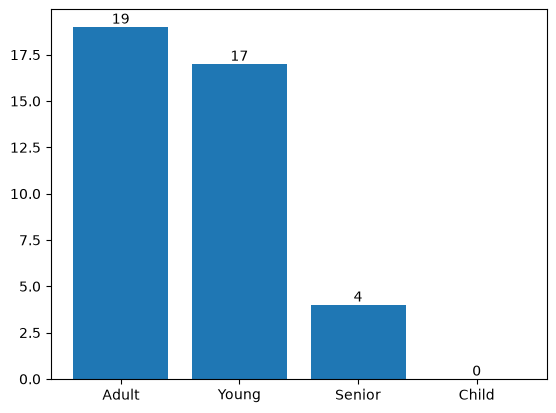

In [18]:
count=df['age_group'].value_counts()
bar=plt.bar(count.index,count.values)
plt.bar_label(bar)
plt.show()

---
## Exercise 6: Stratified Train-Test Split
1. Define feature matrix `X` and target `y`:
   - Let `y = df['churn_risk']`.
   - Let `X` be the numerical features: `['daily_listen_mins', 'songs_skipped_per_day', 'tenure_days', 'skip_rate', 'tier_code']`.
2. Perform an **80/20 train-test split** using `train_test_split()`.
   - Set `random_state=42`.
   - **Crucial**: Use `stratify=y` to preserve the exact class ratio of churn risk!
3. Print the percentage of churn risk (`y == 1`) in both `y_train` and `y_test` to verify that stratification worked perfectly.


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   user_id                    40 non-null     str           
 1   signup_date                40 non-null     datetime64[us]
 2   age                        40 non-null     int64         
 3   subscription_tier          40 non-null     str           
 4   primary_genre              40 non-null     str           
 5   daily_listen_mins          40 non-null     int64         
 6   songs_skipped_per_day      40 non-null     int64         
 7   playlists_created          40 non-null     int64         
 8   churn_risk                 40 non-null     int64         
 9   month                      40 non-null     int32         
 10  day                        40 non-null     str           
 11  tenure_days                40 non-null     int64         
 12  skip_rate            

In [20]:
# TODO 6.1: Define X and y
X=df[['daily_listen_mins', 'songs_skipped_per_day', 'tenure_days', 'skip_rate', 'tier_code']]
y = df['churn_risk']

In [21]:
# TODO 6.2: Perform 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=18
)

In [22]:
# TODO 6.3: Print churn_risk percentage in y_train and y_test
print('*'*50)
print(y_train.value_counts(normalize=True) * 100)
print('*'*50)
print(y_test.value_counts(normalize=True) * 100)

**************************************************
churn_risk
0    75.0
1    25.0
Name: proportion, dtype: float64
**************************************************
churn_risk
0    75.0
1    25.0
Name: proportion, dtype: float64


---
## Exercise 7: Leakage-Free Feature Scaling
1. Initialize `StandardScaler()`.
2. **Strict Leakage Prevention**:
   - Fit and transform the scaler **strictly on `X_train`**: `X_train_scaled = scaler.fit_transform(X_train)`.
   - Transform `X_test` using the parameters learned from train: `X_test_scaled = scaler.transform(X_test)`.
3. Verify that the mean of each column in `X_train_scaled` is approximately `0` and standard deviation is approximately `1`.


In [23]:
# TODO 7.1: Initialize StandardScaler
scaler = StandardScaler()

In [24]:
# TODO 7.2: Fit on X_train, transform X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# TODO 7.3: Verify mean and  of X_train_scaled
X_train_scaled.mean(axis=0)

array([-5.55111512e-17,  2.77555756e-17, -3.12250226e-17,  2.77555756e-17,
                   nan])

In [26]:
#standard deviation
X_train_scaled.std(axis=0)

array([ 1.,  1.,  1.,  1., nan])

---
## Exercise 8: Scikit-Learn Preprocessing Pipeline (Synthesis)
Let's bring everything together into a clean, leakage-free Scikit-Learn Pipeline!
1. From the original DataFrame `df`, select:
   - Numerical features: `['daily_listen_mins', 'songs_skipped_per_day', 'tenure_days']`
   - Categorical features: `['primary_genre', 'device_type']`
2. Build a `ColumnTransformer` named `preprocessor`:
   - Scale numerical features with `StandardScaler()`.
   - Encode categorical features with `OneHotEncoder(drop='first', sparse_output=False)`.
3. Build a complete `Pipeline` named `model_pipeline`:
   - Step 1: `('preprocessor', preprocessor)`
   - Step 2: `('classifier', LogisticRegression(random_state=42))`
4. Split the data using `train_test_split(..., test_size=0.20, random_state=42, stratify=df['churn_risk'])`.
5. Fit `model_pipeline` on the training set and print the test accuracy score!


In [27]:
# TODO 8.1: Define feature subsets

In [28]:
num_features = ['daily_listen_mins', 'songs_skipped_per_day', 'tenure_days']

In [29]:
cat_features = ['primary_genre', 'device_type']

In [30]:
# TODO 8.2: Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'),cat_features)
    ]
)

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [32]:
# TODO 8.3: Build Pipeline with LogisticRegression
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

In [33]:
# TODO 8.4: Split features and target
X_train.isnull().sum()

daily_listen_mins         0
songs_skipped_per_day     0
tenure_days               0
skip_rate                 0
tier_code                24
dtype: int64

In [34]:
y_train.isnull().sum()

np.int64(0)

In [35]:
# TODO 8.5: Fit pipeline and print test accuracy
pipeline.fit(X_train, y_train)

test_accuracy = pipeline.score(X_test, y_test)





In [36]:
test_accuracy 

1.0

---
### 🎉 Congratulations on Completing Assignment 5!
You have mastered:
- Engineering temporal and domain-specific behavioral features.
- Correctly applying ordinal and one-hot encoding.
- Splitting data with stratification to handle class imbalance.
- Enforcing strict train-test separation to eliminate data leakage.
- Building end-to-end preprocessing pipelines with Scikit-Learn!
